<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/statistics/CO2emissionsNorwegianContinentalShelf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Norwegian Continental Shelf CO₂ emissions with NeqSim

This notebook connects authoritative sector statistics to a reproducible offshore export-gas
compression study. It separates **reported sector data** from **NeqSim-calculated process and
fuel scenarios** so that historical evidence is not mistaken for a simulation result.

## Learning objectives

After completing the notebook, you can:

1. interpret observed and forecast Norwegian petroleum-sector emissions;
2. distinguish CO₂ from CO₂-equivalent data and identify dominant source categories;
3. build and run an SRK export-gas compression and cooling process in NeqSim;
4. obtain ISO 6976 fuel properties and convert shaft power into combustion emissions;
5. test discharge-pressure and driver-decarbonization scenarios; and
6. validate mass, energy, composition, phase, and trend consistency.


In [1]:
# Original setup cell, modernized for a clean Google Colab runtime.
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

from importlib.metadata import version
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

neqsim_version = version("neqsim")
python_version = platform.python_version()
java_version = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    check=True,
    text=True,
).stderr.splitlines()[0]

print(f"NeqSim: {neqsim_version}")
print(f"Python: {python_version}")
print(f"Java: {java_version}")


NeqSim: 3.16.0
Python: 3.12.13
Java: openjdk version "17.0.19" 2026-04-21


In [2]:
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 10,
        "legend.fontsize": 9,
    }
)

HOURS_PER_YEAR = 8_760.0
CARBON_TAX_NOK_PER_TONNE = 1_098.0
NORWAY_GRID_G_CO2E_PER_KWH = 11.9


## Literature and authoritative data

- [Norwegian Offshore Directorate: emissions to air](https://www.norskpetroleum.no/en/environment-and-technology/emissions-to-air/)
- [Official 2025 greenhouse-gas spreadsheet](https://www.norskpetroleum.no/wp-content/uploads/17-Klimagassutslipp-historie-prognose-11062025.xlsx)
- [Official 2024 CO₂ source spreadsheet](https://www.norskpetroleum.no/wp-content/uploads/16-CO2-utslipp-fordelt-pa-kilde-tabell-11062025.xlsx)
- [NVE climate declaration for electricity supplied in 2024](https://www.nve.no/nytt-fra-nve/nyheter-energi/klimagassutslipp-knyttet-til-norsk-stroemforbruk-gaar-ned/)
- [NeqSim emissions and sustainability documentation](https://equinor.github.io/neqsim/emissions/index.html)
- [NeqSim standards documentation](https://equinor.github.io/neqsim/standards/)

The earlier notebook linked an inaccessible personal page and a generic Kaggle visualization.
Those links are replaced by primary public sources and current NeqSim documentation.


## 1. Source inventory and preservation checklist

The original notebook contained four substantive learning examples and three visuals:

| Original item | Teaching purpose | Treatment here |
|---|---|---|
| Colab/Python setup | Run the notebook in a hosted environment | Retained and updated to current PyPI |
| Production video | Provide industry context | Retained as an external historical visual |
| NCS emissions trend | Show historical and forecast change | Retained and numerically refreshed |
| 2018 source split | Identify dominant emission sources | Retained as a clearly dated snapshot |

No original cell or functionality is removed. The video is external media, not a NeqSim result.
The next static diagram is its durable teaching fallback if an embedded player is unavailable.


In [3]:
# Original external video example, retained as historical industry context.
from IPython.display import YouTubeVideo

YouTubeVideo("l8lU0A-pmc8", width=600, height=400)


The retained video reflects the industry narrative at the time it was published. It is useful
context, but its statements should not be treated as current emissions data. The official
Norwegian Offshore Directorate tables below provide the dated quantitative evidence.


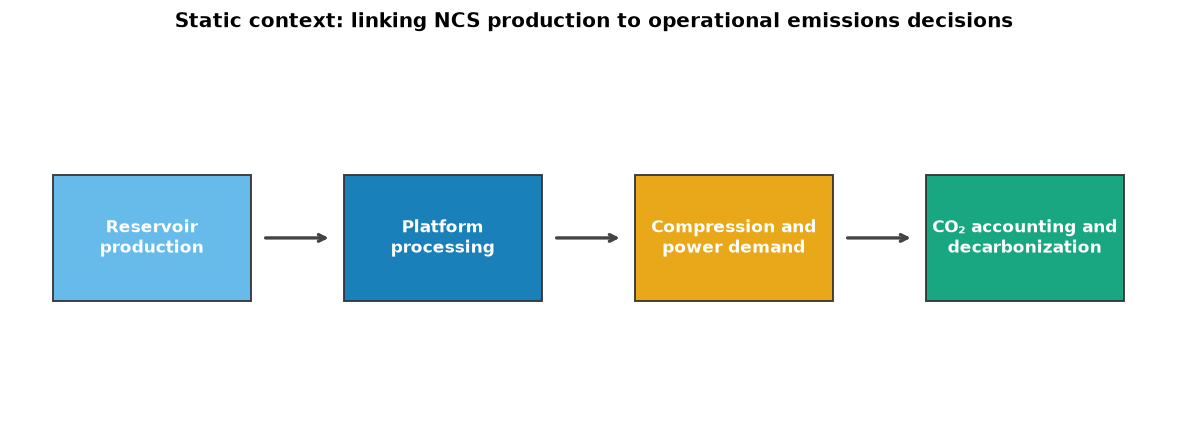

In [4]:
fig, axis = plt.subplots(figsize=(10, 3.8))
axis.set_xlim(0, 10)
axis.set_ylim(0, 4)
axis.axis("off")

steps = [
    (1.2, "Reservoir\nproduction", "#56B4E9"),
    (3.7, "Platform\nprocessing", "#0072B2"),
    (6.2, "Compression and\npower demand", "#E69F00"),
    (8.7, "CO₂ accounting and\ndecarbonization", "#009E73"),
]

for x_position, label, color in steps:
    axis.add_patch(
        plt.Rectangle(
            (x_position - 0.85, 1.35),
            1.7,
            1.3,
            facecolor=color,
            edgecolor="#333333",
            linewidth=1.2,
            alpha=0.9,
        )
    )
    axis.text(
        x_position,
        2.0,
        label,
        color="white",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

for left, right in zip(steps[:-1], steps[1:]):
    axis.annotate(
        "",
        xy=(right[0] - 0.95, 2.0),
        xytext=(left[0] + 0.95, 2.0),
        arrowprops={"arrowstyle": "->", "color": "#444444", "lw": 2},
    )

axis.set_title(
    "Static context: linking NCS production to operational emissions decisions",
    pad=10,
)
fig.tight_layout()
plt.show()


The workflow separates the physical process calculation from emissions accounting. NeqSim
calculates the thermodynamic state, compressor work, cooler duty, and fuel quality; dated public
factors are then applied transparently for policy scenarios.

## 2. Official sector-level evidence

The source reports **greenhouse gases** in million tonnes CO₂e/year. Observed and forecast values
must remain separate: forecasts are planning assumptions, not measured outcomes.


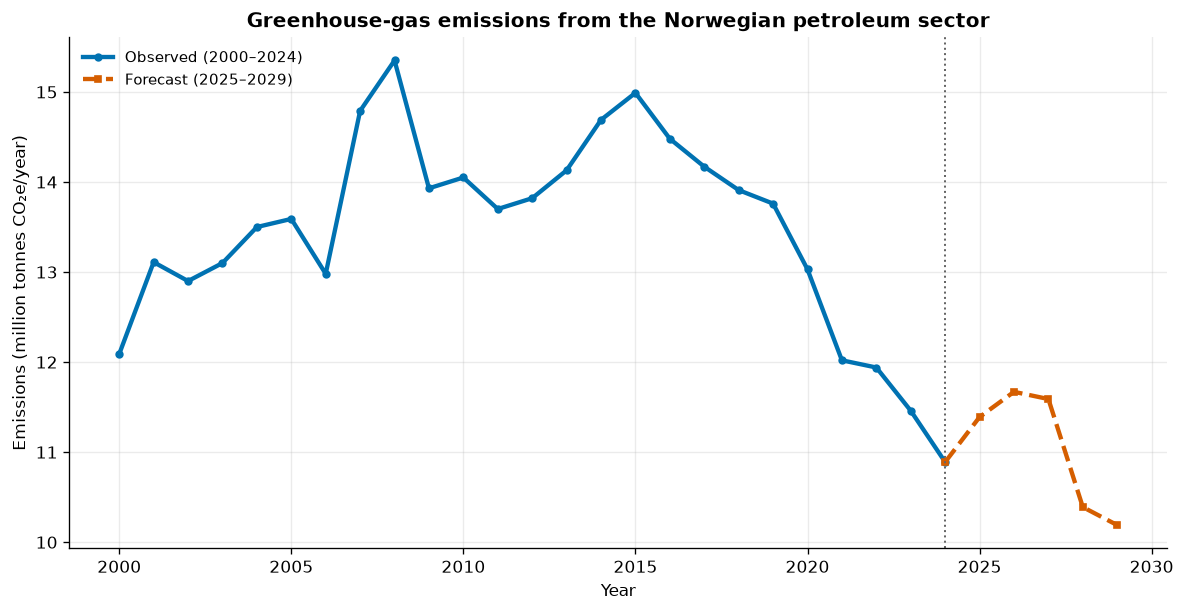

,year,emissions_mt_co2e,series
22,2022,11.94,Observed
23,2023,11.46,Observed
24,2024,10.89,Observed
25,2025,11.39,Forecast
26,2026,11.67,Forecast
27,2027,11.59,Forecast
28,2028,10.39,Forecast
29,2029,10.19,Forecast


In [5]:
# Original NCS emissions-trend example, refreshed from the 11 June 2025 source file.
observed_years = list(range(2000, 2025))
observed_emissions_mt = [
    12.09,
    13.11,
    12.90,
    13.10,
    13.50,
    13.59,
    12.98,
    14.79,
    15.35,
    13.93,
    14.05,
    13.70,
    13.82,
    14.13,
    14.69,
    14.99,
    14.48,
    14.17,
    13.91,
    13.76,
    13.03,
    12.02,
    11.94,
    11.46,
    10.89,
]
forecast_years = list(range(2025, 2030))
forecast_emissions_mt = [11.39, 11.67, 11.59, 10.39, 10.19]

ncs_emissions = pd.DataFrame(
    {
        "year": observed_years + forecast_years,
        "emissions_mt_co2e": observed_emissions_mt + forecast_emissions_mt,
        "series": ["Observed"] * len(observed_years)
        + ["Forecast"] * len(forecast_years),
    }
)

fig, axis = plt.subplots(figsize=(10, 5.2))
axis.plot(
    observed_years,
    observed_emissions_mt,
    color="#0072B2",
    linewidth=2.6,
    marker="o",
    markersize=4,
    label="Observed (2000–2024)",
)
axis.plot(
    [2024] + forecast_years,
    [observed_emissions_mt[-1]] + forecast_emissions_mt,
    color="#D55E00",
    linewidth=2.6,
    linestyle="--",
    marker="s",
    markersize=4,
    label="Forecast (2025–2029)",
)
axis.axvline(2024, color="#666666", linestyle=":", linewidth=1.2)
axis.set(
    title="Greenhouse-gas emissions from the Norwegian petroleum sector",
    xlabel="Year",
    ylabel="Emissions (million tonnes CO₂e/year)",
)
axis.grid(alpha=0.25)
axis.legend(frameon=False)
fig.tight_layout()
plt.show()

ncs_emissions.tail(8)


Observed emissions peaked at 15.35 Mt CO₂e in 2008 and declined to 10.89 Mt CO₂e in 2024, a
29.1% reduction from that peak. The 2025–2029 values are the Directorate's 11 June 2025
projection and should be replaced when a newer official dataset is published.


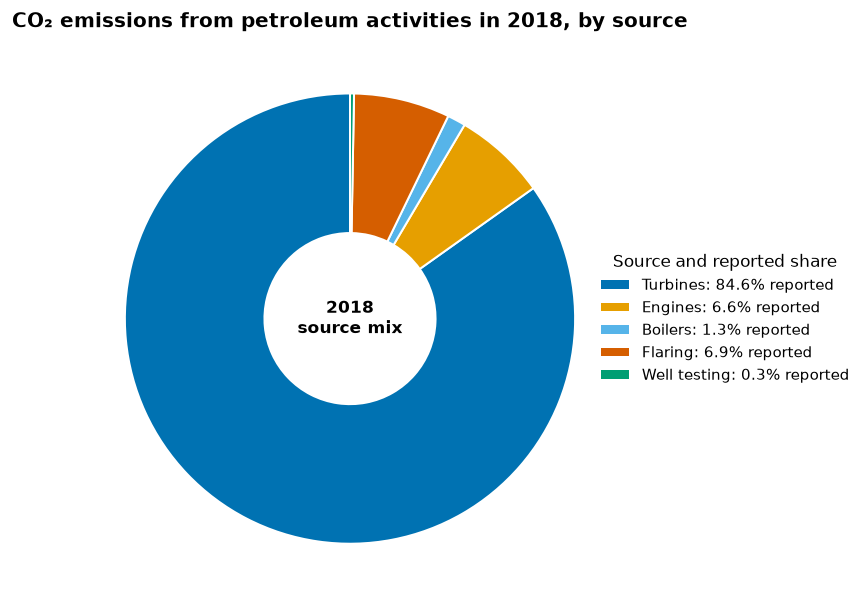

,source,co2_mt,reported_share
0,Turbines,10.964207,0.846
1,Engines,0.860556,0.066
2,Boilers,0.169671,0.013
3,Flaring,0.891774,0.069
4,Well testing,0.037000,0.003


In [6]:
# Original 2018 source-share example, retained as a documented historical snapshot.
source_2018 = pd.DataFrame(
    {
        "source": ["Turbines", "Engines", "Boilers", "Flaring", "Well testing"],
        "co2_mt": [10.964207, 0.860556, 0.169671, 0.891774, 0.037000],
        "reported_share": [0.846, 0.066, 0.013, 0.069, 0.003],
    }
)

fig, axis = plt.subplots(figsize=(9.4, 5.2))
colors = ["#0072B2", "#E69F00", "#56B4E9", "#D55E00", "#009E73"]
wedges, _ = axis.pie(
    source_2018["co2_mt"],
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.2, "width": 0.62},
)
legend_labels = [
    f"{source}: {100.0 * share:.1f}% reported"
    for source, share in zip(
        source_2018["source"],
        source_2018["reported_share"],
    )
]
axis.legend(
    wedges,
    legend_labels,
    title="Source and reported share",
    loc="center left",
    bbox_to_anchor=(0.92, 0.5),
    frameon=False,
)
axis.text(0.0, 0.0, "2018\nsource mix", ha="center", va="center", fontweight="bold")
axis.set_title("CO₂ emissions from petroleum activities in 2018, by source")
fig.tight_layout()
plt.show()

source_2018


The original 2018 chart remains useful because it shows that turbines dominated the source mix.
Its five listed categories sum to 99.7% of the reported share; the small residual is not silently
redistributed. This is a historical source table, not a NeqSim calculation.


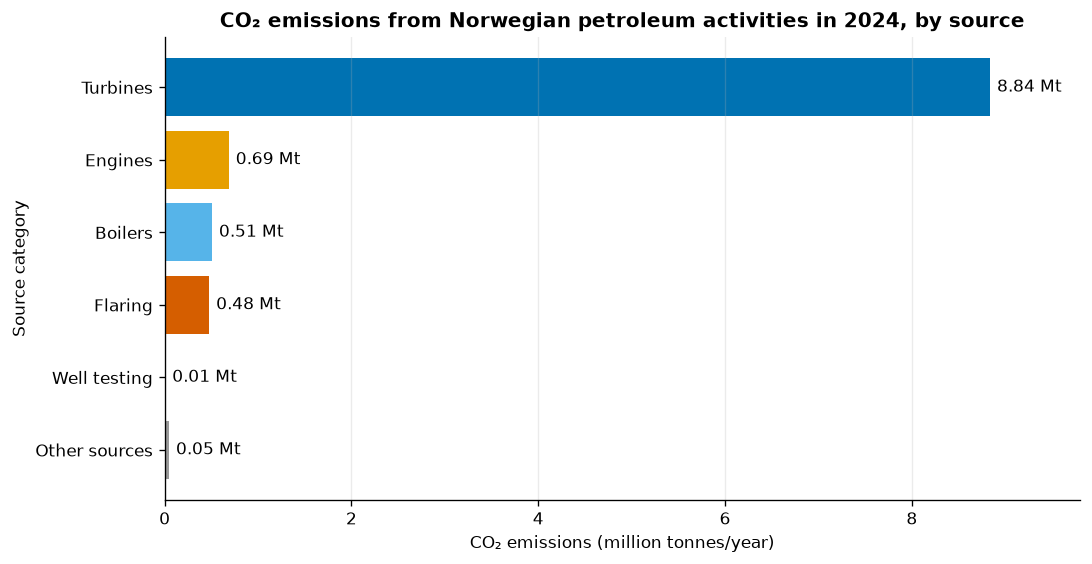

,source,co2_mt,share_percent
0,Turbines,8.84,83.553875
1,Engines,0.69,6.521739
2,Boilers,0.51,4.820416
3,Flaring,0.48,4.536862
4,Well testing,0.01,0.094518
5,Other sources,0.05,0.472590


In [7]:
source_2024 = pd.DataFrame(
    {
        "source": [
            "Turbines",
            "Engines",
            "Boilers",
            "Flaring",
            "Well testing",
            "Other sources",
        ],
        "co2_mt": [8.84, 0.69, 0.51, 0.48, 0.01, 0.05],
    }
)
source_2024["share_percent"] = (
    100.0 * source_2024["co2_mt"] / source_2024["co2_mt"].sum()
)

fig, axis = plt.subplots(figsize=(9.2, 4.8))
bars = axis.barh(
    source_2024["source"],
    source_2024["co2_mt"],
    color=["#0072B2", "#E69F00", "#56B4E9", "#D55E00", "#009E73", "#999999"],
)
axis.invert_yaxis()
axis.set(
    title="CO₂ emissions from Norwegian petroleum activities in 2024, by source",
    xlabel="CO₂ emissions (million tonnes/year)",
    ylabel="Source category",
)
axis.bar_label(
    bars,
    labels=[f"{value:.2f} Mt" for value in source_2024["co2_mt"]],
    padding=4,
)
axis.set_xlim(0.0, 9.8)
axis.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

source_2024


Turbines contributed 8.84 of 10.58 Mt CO₂ in the 2024 source table, or 83.6%. This makes power
generation and compression efficiency a natural engineering focus. The 10.58 Mt CO₂ source
total is narrower than the 10.89 Mt CO₂e greenhouse-gas total because the latter also includes
methane expressed on a CO₂-equivalent basis.

## 3. Calculation basis

For a driver that supplies shaft power $P_s$ in W, the required fuel volume at standard
conditions is calculated from the ISO 6976 lower heating value $H_L$ in kJ/Sm³ and efficiency
$\eta$:

$$
\dot{V}_{f} = \frac{3.6 P_s}{\eta H_L}
$$

The factor 3.6 converts W to kJ/h. The carbon atoms per mole of fuel are

$$
n_C = \sum_i z_i n_{C,i}
$$

Combustion CO₂ per standard cubic metre is then

$$
e_{\mathrm{CO_2}} = \frac{P_{\mathrm{ref}} n_C M_{\mathrm{CO_2}}}{ZRT_{\mathrm{ref}}}
$$

Here $e_{\mathrm{CO_2}}$ is kg CO₂/Sm³, $z_i$ is mole fraction, $n_{C,i}$ is the number of
carbon atoms in component $i$, $n_C$ is carbon atoms per fuel mole, $Z$ is the ISO 6976
compression factor, $R$ is the gas constant,
and $M_{\mathrm{CO_2}}$ is 0.0440095 kg/mol. Annual emissions and carbon-tax exposure are

$$
m_{\mathrm{annual}} = \frac{\dot{V}_{f} e_{\mathrm{CO_2}} t}{1000}
$$

$$
C_{\mathrm{tax}} = m_{\mathrm{annual}} c_{\mathrm{tax}}
$$

where $t$ is operating hours/year and $c_{\mathrm{tax}}$ is NOK/tonne CO₂. These are transparent
screening equations, not a substitute for verified regulatory reporting.


## 4. Build a reusable NeqSim export-compression process

The example uses the SRK equation of state with the classic mixing rule for a dry, sweet natural
gas. A named feed stream enters at 30 °C and 30 bara. A compressor raises pressure, and an
aftercooler returns the export gas to 40 °C. The function returns reusable scalar outputs and
checks the process before it is used in emissions scenarios.


In [8]:
from neqsim.process import clearProcess, compressor, cooler, runProcess, stream
from neqsim.standards import ISO6976
from neqsim.thermo import fluid


GAS_COMPOSITION = {
    "methane": 0.820,
    "ethane": 0.080,
    "propane": 0.035,
    "i-butane": 0.010,
    "n-butane": 0.015,
    "CO2": 0.020,
    "nitrogen": 0.020,
}

FEED_TEMPERATURE_K = 303.15
FEED_PRESSURE_BARA = 30.0
FEED_FLOW_SM3_DAY = 1_000_000.0
AFTERCOOLER_TEMPERATURE_K = 313.15
POLYTROPIC_EFFICIENCY = 0.75


In [9]:
def run_export_compression(outlet_pressure_bara):
    clearProcess()

    export_gas = fluid(
        "srk",
        temperature=FEED_TEMPERATURE_K,
        pressure=FEED_PRESSURE_BARA,
    )
    for component_name, mole_fraction in GAS_COMPOSITION.items():
        export_gas.addComponent(component_name, mole_fraction)

    export_gas.setMixingRule("classic")

    feed_stream = stream("export gas feed", export_gas)
    feed_stream.setFlowRate(FEED_FLOW_SM3_DAY, "Sm3/day")

    export_compressor = compressor(
        "export compressor",
        feed_stream,
        pres=outlet_pressure_bara,
    )
    export_compressor.setPolytropicEfficiency(POLYTROPIC_EFFICIENCY)

    hot_discharge = export_compressor.getOutletStream()
    export_aftercooler = cooler("export aftercooler", hot_discharge)
    export_aftercooler.setOutTemperature(AFTERCOOLER_TEMPERATURE_K)

    runProcess()

    cooled_export = export_aftercooler.getOutletStream()
    inlet_mass_flow = feed_stream.getFlowRate("kg/hr")
    outlet_mass_flow = cooled_export.getFlowRate("kg/hr")
    mass_residual = abs(inlet_mass_flow - outlet_mass_flow) / inlet_mass_flow

    compressor_enthalpy_change = (
        hot_discharge.getFluid().getEnthalpy()
        - feed_stream.getFluid().getEnthalpy()
    )
    compressor_power = export_compressor.getPower()
    compressor_energy_residual = abs(
        compressor_enthalpy_change - compressor_power
    ) / compressor_power

    cooler_enthalpy_change = (
        cooled_export.getFluid().getEnthalpy()
        - hot_discharge.getFluid().getEnthalpy()
    )
    cooler_duty = export_aftercooler.getDuty()
    cooler_energy_residual = abs(
        cooler_enthalpy_change - cooler_duty
    ) / abs(cooler_duty)

    return {
        "outlet_pressure_bara": outlet_pressure_bara,
        "power_mw": compressor_power / 1.0e6,
        "hot_discharge_c": hot_discharge.getTemperature("C"),
        "cooler_duty_mw": cooler_duty / 1.0e6,
        "outlet_temperature_c": cooled_export.getTemperature("C"),
        "inlet_mass_flow_kg_h": inlet_mass_flow,
        "outlet_mass_flow_kg_h": outlet_mass_flow,
        "mass_residual": mass_residual,
        "compressor_energy_residual": compressor_energy_residual,
        "cooler_energy_residual": cooler_energy_residual,
        "outlet_phase_count": int(
            cooled_export.getThermoSystem().getNumberOfPhases()
        ),
    }


In [10]:
base_case = run_export_compression(120.0)
base_case_table = pd.DataFrame(
    {
        "Metric": [
            "Feed flow",
            "Discharge pressure",
            "Compressor power",
            "Hot discharge temperature",
            "Aftercooler duty",
            "Cooled export temperature",
            "Outlet phases",
            "Relative mass residual",
            "Compressor energy residual",
            "Cooler energy residual",
        ],
        "Value": [
            f"{FEED_FLOW_SM3_DAY:,.0f} Sm³/day",
            f"{base_case['outlet_pressure_bara']:.1f} bara",
            f"{base_case['power_mw']:.3f} MW",
            f"{base_case['hot_discharge_c']:.1f} °C",
            f"{base_case['cooler_duty_mw']:.3f} MW",
            f"{base_case['outlet_temperature_c']:.1f} °C",
            str(base_case["outlet_phase_count"]),
            f"{base_case['mass_residual']:.3e}",
            f"{base_case['compressor_energy_residual']:.3e}",
            f"{base_case['cooler_energy_residual']:.3e}",
        ],
    }
)
base_case_table


,Metric,Value
0,Feed flow,"1,000,000 Sm³/day"
1,Discharge pressure,120.0 bara
2,Compressor power,1.866 MW
3,Hot discharge temperature,134.3 °C
4,Aftercooler duty,-2.611 MW
5,Cooled export temperature,40.0 °C
6,Outlet phases,1
7,Relative mass residual,0.000e+00
8,Compressor energy residual,0.000e+00
9,Cooler energy residual,0.000e+00


The base case is an end-to-end NeqSim process, not an isolated equation. The named stream,
compressor, and cooler can be inserted into a larger `ProcessSystem`. Negative cooler duty means
heat is removed. Exact enthalpy-work and enthalpy-duty checks verify the process energy accounting.

## 5. Pressure sensitivity

Higher export pressure increases the specific compression work and usually raises the uncooled
discharge temperature. The sensitivity below re-runs the complete process for each pressure.


In [11]:
pressure_cases_bara = [60.0, 80.0, 100.0, 120.0, 140.0]
pressure_results = pd.DataFrame(
    [run_export_compression(pressure) for pressure in pressure_cases_bara]
)

pressure_results[
    [
        "outlet_pressure_bara",
        "power_mw",
        "hot_discharge_c",
        "cooler_duty_mw",
        "mass_residual",
        "outlet_phase_count",
    ]
]


,outlet_pressure_bara,power_mw,hot_discharge_c,cooler_duty_mw,mass_residual,outlet_phase_count
0,60.0,0.857701,79.892968,-0.969024,0.0,1
1,80.0,1.255539,101.979570,-1.587583,0.0,1
2,100.0,1.583853,119.591040,-2.129484,0.0,1
3,120.0,1.866389,134.251400,-2.610898,0.0,1
4,140.0,2.116344,146.809982,-3.038667,0.0,1


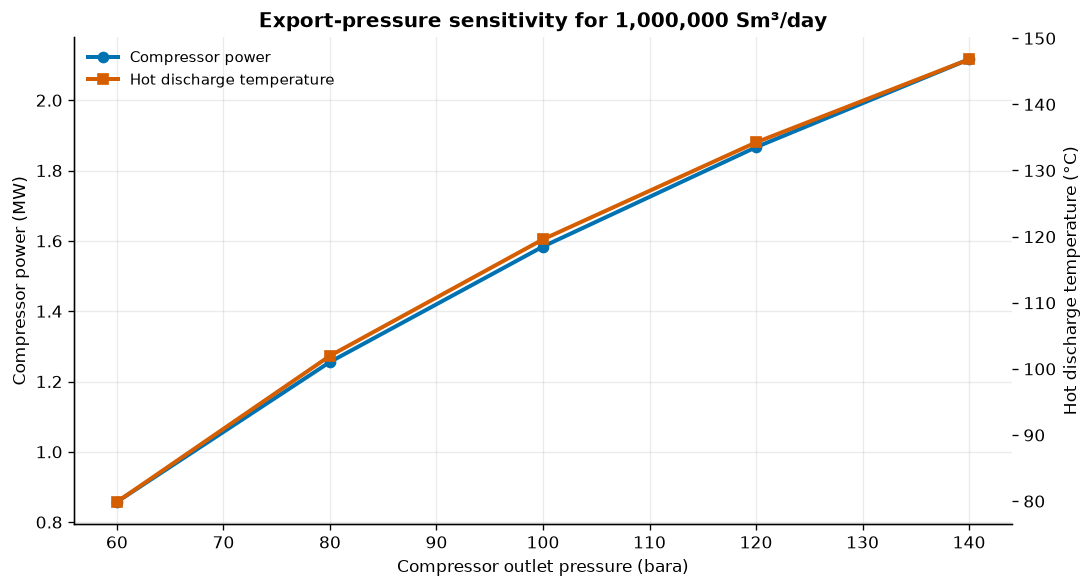

In [12]:
fig, left_axis = plt.subplots(figsize=(9.2, 5.0))
right_axis = left_axis.twinx()

power_line = left_axis.plot(
    pressure_results["outlet_pressure_bara"],
    pressure_results["power_mw"],
    color="#0072B2",
    marker="o",
    linewidth=2.4,
    label="Compressor power",
)
temperature_line = right_axis.plot(
    pressure_results["outlet_pressure_bara"],
    pressure_results["hot_discharge_c"],
    color="#D55E00",
    marker="s",
    linewidth=2.4,
    label="Hot discharge temperature",
)

left_axis.set(
    title="Export-pressure sensitivity for 1,000,000 Sm³/day",
    xlabel="Compressor outlet pressure (bara)",
    ylabel="Compressor power (MW)",
)
right_axis.set_ylabel("Hot discharge temperature (°C)")
left_axis.grid(alpha=0.25)

lines = power_line + temperature_line
labels = [line.get_label() for line in lines]
left_axis.legend(lines, labels, loc="upper left", frameon=False)
fig.tight_layout()
plt.show()


Both power and discharge temperature rise monotonically with pressure. This is physically
consistent: the compressor must supply more work as the pressure ratio increases. The cooled
export remains single phase over the tested range, and all mass residuals remain negligible.

## 6. ISO 6976 fuel quality and driver scenarios

NeqSim's ISO 6976 implementation supplies the lower heating value and standard compression
factor. Only `init(0)` is used before the standard calculation because composition initialization
is sufficient; no higher thermodynamic initialization level is requested.


In [13]:
def calculate_fuel_metrics(composition):
    fuel_gas = fluid("srk", temperature=288.15, pressure=1.01325)
    for component_name, mole_fraction in composition.items():
        fuel_gas.addComponent(component_name, mole_fraction)

    fuel_gas.init(0)
    iso_6976 = ISO6976(
        fuel_gas,
        numberunit="volume",
        referencetemperaturevolume="15",
        referencetemperaturecombustion="15",
    )

    lower_heating_value = iso_6976.getValue("InferiorCalorificValue")
    compression_factor = iso_6976.getValue("CompressionFactor")
    carbon_atoms_per_mole = 0.0

    for component_index in range(fuel_gas.getNumberOfComponents()):
        component = fuel_gas.getComponent(component_index)
        carbon_atoms = component.getElements().getNumberOfElements("C")
        carbon_atoms_per_mole += component.getz() * carbon_atoms

    pressure_pa = 101_325.0
    reference_temperature_k = 288.15
    gas_constant = 8.314462618
    co2_molar_mass_kg_mol = 0.0440095
    molar_density = pressure_pa / (
        compression_factor * gas_constant * reference_temperature_k
    )
    co2_kg_sm3 = (
        molar_density * carbon_atoms_per_mole * co2_molar_mass_kg_mol
    )

    return {
        "lower_heating_value_kj_sm3": lower_heating_value,
        "compression_factor": compression_factor,
        "carbon_atoms_per_mole": carbon_atoms_per_mole,
        "co2_kg_sm3": co2_kg_sm3,
    }


base_fuel_metrics = calculate_fuel_metrics(GAS_COMPOSITION)
hydrogen_blend_composition = {
    component: 0.8 * mole_fraction
    for component, mole_fraction in GAS_COMPOSITION.items()
}
hydrogen_blend_composition["hydrogen"] = 0.2
hydrogen_fuel_metrics = calculate_fuel_metrics(hydrogen_blend_composition)

pd.DataFrame(
    [base_fuel_metrics, hydrogen_fuel_metrics],
    index=["Base fuel gas", "20 mol% hydrogen blend"],
)


,lower_heating_value_kj_sm3,compression_factor,carbon_atoms_per_mole,co2_kg_sm3
Base fuel gas,38619.494472,0.996958,1.205,2.249677
20 mol% hydrogen blend,32910.266734,0.998053,0.964,1.797767


In [14]:
def annual_combustion_emissions(power_mw, efficiency, fuel_metrics):
    power_w = power_mw * 1.0e6
    fuel_flow_sm3_h = (
        3.6
        * power_w
        / (
            efficiency
            * fuel_metrics["lower_heating_value_kj_sm3"]
        )
    )
    annual_co2_tonnes = (
        fuel_flow_sm3_h
        * fuel_metrics["co2_kg_sm3"]
        * HOURS_PER_YEAR
        / 1_000.0
    )
    return fuel_flow_sm3_h, annual_co2_tonnes


scenario_rows = []
for name, efficiency, fuel_metrics in [
    ("Base gas turbine", 0.35, base_fuel_metrics),
    ("Efficient gas turbine", 0.42, base_fuel_metrics),
    ("20 mol% H₂ fuel blend", 0.35, hydrogen_fuel_metrics),
]:
    fuel_flow, annual_emissions = annual_combustion_emissions(
        base_case["power_mw"],
        efficiency,
        fuel_metrics,
    )
    scenario_rows.append(
        {
            "scenario": name,
            "shaft_efficiency": efficiency,
            "fuel_flow_sm3_h": fuel_flow,
            "annual_co2_tonnes": annual_emissions,
            "carbon_tax_mnok_year": (
                annual_emissions * CARBON_TAX_NOK_PER_TONNE / 1.0e6
            ),
        }
    )

annual_power_mwh = base_case["power_mw"] * HOURS_PER_YEAR
electric_emissions_tonnes = (
    annual_power_mwh * NORWAY_GRID_G_CO2E_PER_KWH / 1_000.0
)
scenario_rows.append(
    {
        "scenario": "Norwegian grid electricity",
        "shaft_efficiency": 1.0,
        "fuel_flow_sm3_h": 0.0,
        "annual_co2_tonnes": electric_emissions_tonnes,
        "carbon_tax_mnok_year": 0.0,
    }
)

driver_scenarios = pd.DataFrame(scenario_rows)
driver_scenarios


,scenario,shaft_efficiency,fuel_flow_sm3_h,annual_co2_tonnes,carbon_tax_mnok_year
0,Base gas turbine,0.35,497.084280,9796.126256,10.756147
1,Efficient gas turbine,0.42,414.236900,8163.438547,8.963456
2,20 mol% H₂ fuel blend,0.35,583.317777,9186.346353,10.086608
3,Norwegian grid electricity,1.00,0.000000,194.559851,0.000000


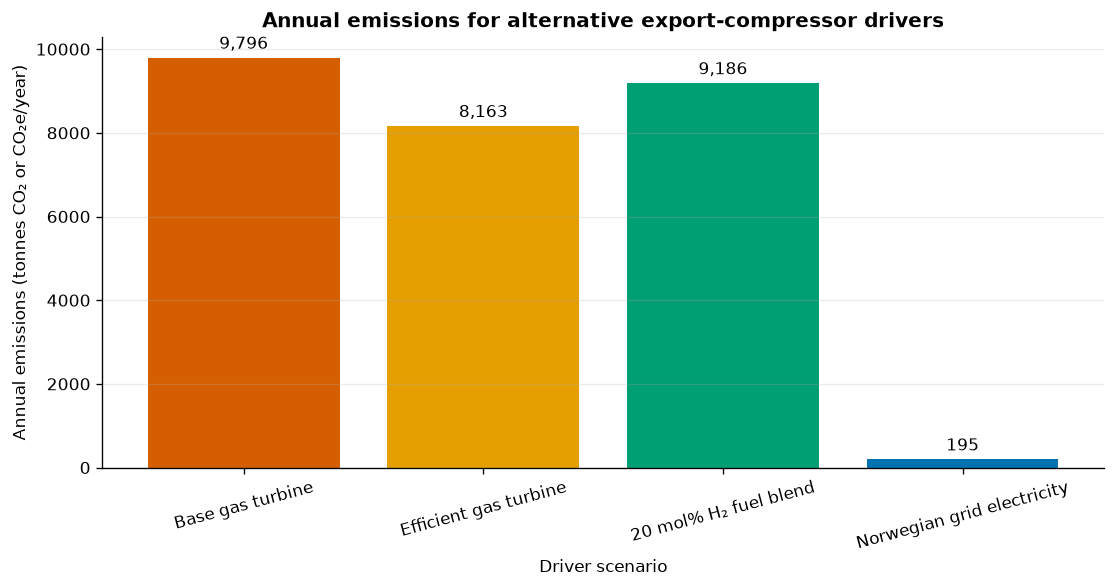

In [15]:
fig, axis = plt.subplots(figsize=(9.4, 5.0))
scenario_colors = ["#D55E00", "#E69F00", "#009E73", "#0072B2"]
bars = axis.bar(
    driver_scenarios["scenario"],
    driver_scenarios["annual_co2_tonnes"],
    color=scenario_colors,
)
axis.set(
    title="Annual emissions for alternative export-compressor drivers",
    xlabel="Driver scenario",
    ylabel="Annual emissions (tonnes CO₂ or CO₂e/year)",
)
axis.bar_label(
    bars,
    labels=[
        f"{value:,.0f}"
        for value in driver_scenarios["annual_co2_tonnes"]
    ],
    padding=3,
)
axis.tick_params(axis="x", rotation=15)
axis.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()


Improving gas-turbine efficiency reduces both fuel demand and CO₂. A 20 mol% hydrogen blend
reduces carbon per unit of fuel gas, but it also changes heating value, so composition-aware ISO
6976 calculation is essential. Norwegian grid electricity has no direct offshore combustion
emissions; the plotted value applies NVE's 2024 physical-delivery factor of 11.9 g CO₂e/kWh.
It is a scenario factor, not a claim about contractual electricity attributes.

## 7. Validation gates

The checks below test data provenance, thermodynamic composition, material and energy closure,
phase behavior, expected pressure trends, and scenario ordering. Failing a check stops execution.


In [16]:
checks = {}

checks["gas composition sums to one"] = np.isclose(
    sum(GAS_COMPOSITION.values()),
    1.0,
    atol=1.0e-12,
)
checks["hydrogen blend sums to one"] = np.isclose(
    sum(hydrogen_blend_composition.values()),
    1.0,
    atol=1.0e-12,
)
checks["2024 CO2 source total is 10.58 Mt"] = np.isclose(
    source_2024["co2_mt"].sum(),
    10.58,
    atol=1.0e-12,
)
checks["2024 CO2e total is 10.89 Mt"] = np.isclose(
    observed_emissions_mt[-1],
    10.89,
    atol=1.0e-12,
)
checks["base power is finite and positive"] = (
    np.isfinite(base_case["power_mw"]) and base_case["power_mw"] > 0.0
)
checks["base mass balance closes"] = base_case["mass_residual"] < 1.0e-12
checks["compressor energy balance closes"] = (
    base_case["compressor_energy_residual"] < 1.0e-12
)
checks["cooler energy balance closes"] = (
    base_case["cooler_energy_residual"] < 1.0e-12
)
checks["aftercooler removes heat"] = base_case["cooler_duty_mw"] < 0.0
checks["cooled export is single phase"] = base_case["outlet_phase_count"] == 1
checks["pressure cases all converge"] = pressure_results["power_mw"].notna().all()
checks["power rises with pressure"] = pressure_results["power_mw"].is_monotonic_increasing
checks["discharge temperature rises with pressure"] = (
    pressure_results["hot_discharge_c"].is_monotonic_increasing
)
checks["all sensitivity mass balances close"] = (
    pressure_results["mass_residual"].max() < 1.0e-12
)
checks["ISO 6976 LHV is plausible"] = (
    30_000.0
    < base_fuel_metrics["lower_heating_value_kj_sm3"]
    < 50_000.0
)
checks["CO2 factor is plausible"] = (
    1.5 < base_fuel_metrics["co2_kg_sm3"] < 3.0
)
checks["hydrogen blend lowers carbon factor"] = (
    hydrogen_fuel_metrics["co2_kg_sm3"]
    < base_fuel_metrics["co2_kg_sm3"]
)
checks["efficient turbine lowers emissions"] = (
    driver_scenarios.loc[1, "annual_co2_tonnes"]
    < driver_scenarios.loc[0, "annual_co2_tonnes"]
)
checks["hydrogen blend lowers emissions"] = (
    driver_scenarios.loc[2, "annual_co2_tonnes"]
    < driver_scenarios.loc[0, "annual_co2_tonnes"]
)
checks["electric scenario is lowest"] = (
    driver_scenarios.loc[3, "annual_co2_tonnes"]
    == driver_scenarios["annual_co2_tonnes"].min()
)

validation_table = pd.DataFrame(
    {
        "check": list(checks),
        "passed": list(checks.values()),
    }
)
assert validation_table["passed"].all(), validation_table

print(f"Engineering checks passed: {validation_table['passed'].sum()}/{len(checks)}")
print(f"Maximum relative mass residual: {pressure_results['mass_residual'].max():.3e}")
validation_table


Engineering checks passed: 20/20
Maximum relative mass residual: 0.000e+00


,check,passed
0,gas composition sums to one,True
1,hydrogen blend sums to one,True
2,2024 CO2 source total is 10.58 Mt,True
3,2024 CO2e total is 10.89 Mt,True
4,base power is finite and positive,True
5,base mass balance closes,True
6,compressor energy balance closes,True
7,cooler energy balance closes,True
8,aftercooler removes heat,True
9,cooled export is single phase,True


## 8. Interpretation, applicability, and limitations

- **What NeqSim demonstrates:** SRK fluid configuration, named process streams, compressor and
  cooler composition, process execution, result retrieval, ISO 6976 gas quality, repeated
  operating cases, and material/energy validation.
- **What the public data demonstrates:** sector-scale trends and source categories. These values
  are not produced by NeqSim.
- **Boundary:** the process case represents one illustrative export compressor, not the full NCS.
  It excludes methane leakage, flaring, diesel, start-up, availability, upstream treatment, and
  construction emissions.
- **Model scope:** SRK is appropriate for this dry-gas screening case. Wet gas, glycol, produced
  water, or acid-gas partitioning may require CPA or another validated model.
- **Driver scope:** turbine efficiencies, 8,760 h/year, and 20 mol% hydrogen are scenarios, not
  project guarantees. Hydrogen compatibility, NOx, safety, and supply-chain emissions require
  separate assessment.
- **Policy scope:** the 2026 tax factor is NOK 1,098/t CO₂ for combusted natural gas. EU ETS cost
  and free allocations are intentionally excluded.

No NeqSim library defect was found while building this notebook.

## 9. Practical exercises

1. Change export flow and determine whether compressor power remains approximately proportional.
2. Replace SRK with PR and compare power, discharge temperature, and phase count.
3. Add water and test whether the cooled export remains single phase.
4. Vary hydrogen from 0 to 30 mol% while preserving a normalized fuel composition.
5. Add operating availability and an EU ETS price to create a broader cost scenario.
6. Replace the 2025 forecast when the Directorate publishes a newer official spreadsheet.

## Final engineering conclusion

The official 2024 source table attributes 83.6% of petroleum-activity CO₂ to turbines. In the
illustrative NeqSim workflow, export pressure directly controls compressor work and therefore the
fuel and emissions required by a gas-driven compressor. Efficiency improvement, lower-carbon
fuel, and electrification can be compared on one transparent calculation basis, while keeping
reported statistics and simulated scenarios clearly separated.
